## 1) Libraries Installation
##### The cell below is to help you keep track the libraries used and install them quickly.
##### Ensure the correct library names are used, and follow the syntax: **%pip install PACKAGE_NAME**.

In [1]:
%pip install pandas
%pip install matplotlib
%pip install numpy
%pip install statsmodels
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## 2) Main Section for Code
### **ALL code for machine learning and dataset analysis** should be entered below.
##### Ensure that your code is clear and readable.
##### Remember to include comments and markdown notes as necessary to explain and highlight important segments of your code.

In [2]:
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import root_mean_squared_error, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

In [3]:
folderpath = 'data/'

filepaths = {}
for file in os.listdir(folderpath):
  filepaths[file] = 'data/' + file

print(filepaths)

{'Quarterly Data.csv': 'data/Quarterly Data.csv', 'Monthly Data.csv': 'data/Monthly Data.csv', 'Variable Description.csv': 'data/Variable Description.csv'}


## Importing data from csv file
First, we get the shape of the quarterly csv and preview the top few rows.

In [4]:
quarterly = pd.read_csv(filepaths['Quarterly Data.csv'], skiprows=[1,2])
print("No. of rows: {}\nNo. of cols: {}".format(*quarterly.shape))
quarterly.head()

No. of rows: 263
No. of cols: 246


,sasdate,GDPC1,PCECC96,PCDGx,PCESVx,PCNDx,GPDIC1,FPIx,Y033RC1Q027SBEAx,PNFIx,PRFIx,A014RE1Q156NBEA,GCEC1,A823RL1Q225SBEA,FGRECPTx,SLCEx,EXPGSC1,IMPGSC1,DPIC96,OUTNFB,OUTBS,OUTMS,INDPRO,IPFINAL,IPCONGD,IPMAT,IPDMAT,IPNMAT,IPDCONGD,IPB51110SQ,IPNCONGD,IPBUSEQ,IPB51220SQ,TCU,CUMFNS,PAYEMS,USPRIV,MANEMP,SRVPRD,USGOOD,...,CPITRNSL,CPIMEDSL,CUSR0000SAC,CUSR0000SAD,CUSR0000SAS,CPIULFSL,CUSR0000SA0L2,CUSR0000SA0L5,CES0600000008,DTCOLNVHFNM,DTCTHFNM,INVEST,HWIURATIOx,CLAIMSx,BUSINVx,ISRATIOx,CONSPIx,CP3M,COMPAPFF,PERMITNE,PERMITMW,PERMITS,PERMITW,NIKKEI225,NASDAQCOM,CUSR0000SEHC,TLBSNNCBx,TLBSNNCBBDIx,TTAABSNNCBx,TNWMVBSNNCBx,TNWMVBSNNCBBDIx,TLBSNNBx,TLBSNNBBDIx,TABSNNBx,TNWBSNNBx,TNWBSNNBBDIx,CNCFx,S&P 500,S&P div yield,S&P PE ratio
0,3/1/1959,3352.129,2039.017,68.6651,1374.1739,689.1172,354.894,357.0174,47.8021,171.0783,282.9707,0.8,1142.671,-7.7,556.0802,531.4011,89.697,115.440,2327.444,14.441,14.606,NaN,22.3558,22.4273,31.8213,20.6337,12.5197,31.1752,19.1404,17.8040,38.3319,8.1551,22.9100,NaN,81.3723,52726.6667,44609.0000,15124.0000,33808.3333,18918.3333,...,29.4333,21.2000,33.2667,38.1667,22.9667,28.9000,30.7000,29.6000,2.1400,6486.6667,12315.0000,83.1243,0.3643,NaN,85230.5200,1.5428,0.1256,NaN,NaN,NaN,NaN,NaN,NaN,708.7090,NaN,NaN,2.36,0.0189,3.11,1676.64,1341.67,333245.24,266668.11,2426352.41,2092.54,1674.48,124.9663,55.5167,3.1765,18.6211
1,6/1/1959,3427.667,2070.508,71.2495,1394.7096,694.8197,382.500,368.0640,49.2332,176.0004,292.8479,1.4,1156.740,7.6,578.9494,532.5791,88.981,121.057,2364.977,14.857,14.988,NaN,23.4400,23.0977,32.4535,22.1139,13.7015,32.8100,19.8616,18.7504,38.8789,8.7169,23.1673,NaN,84.5589,53517.3333,45371.3333,15475.3333,34147.6667,19369.6667,...,29.7333,21.4000,33.2667,38.3667,23.1667,29.1000,30.7333,29.6333,2.1667,6776.3333,12685.3333,80.4129,0.4738,NaN,87393.1872,1.5256,0.1269,NaN,NaN,NaN,NaN,NaN,NaN,780.3647,NaN,NaN,2.46,0.0194,3.15,1637.49,1294.15,345845.01,273329.36,2434975.21,2088.55,1650.63,126.5305,57.5067,3.1012,19.2899
2,9/1/1959,3430.057,2092.138,72.6270,1413.6627,697.4699,357.798,371.9585,50.8372,180.7406,287.3778,0.1,1166.589,5.5,564.7381,532.8908,97.562,122.212,2361.784,14.834,14.960,NaN,22.4813,23.4100,32.8148,19.8204,11.3961,32.9310,19.9113,18.1033,39.3954,8.8899,23.6225,NaN,80.4988,53522.6667,45325.0000,15359.6667,34312.6667,19210.0000,...,29.9333,21.6000,33.3667,38.4667,23.4000,29.2667,30.9333,29.8333,2.1700,7278.0000,13442.3333,77.7318,0.4567,NaN,88795.9984,1.5772,0.1310,NaN,NaN,NaN,NaN,NaN,NaN,862.0388,NaN,NaN,2.44,0.0189,3.16,1703.15,1320.72,354808.05,275139.48,2434604.03,2079.21,1612.34,128.9557,58.7300,3.0720,18.9544
3,12/1/1959,3439.832,2094.495,69.1573,1430.8157,701.7617,369.442,367.6452,50.7342,180.2333,279.2502,0.8,1157.052,-3.9,566.5192,530.0971,92.734,119.109,2378.605,14.790,14.966,NaN,22.5888,23.1528,32.4794,20.2921,11.8659,32.6093,18.8834,15.4905,39.6082,8.7005,24.1272,NaN,80.0757,53722.0000,45416.3333,15343.6667,34569.3333,19152.6667,...,30.1000,21.7667,33.5000,38.5000,23.6333,29.4333,31.0333,29.9333,2.1800,7434.3333,13917.0000,76.0913,0.4080,NaN,89136.9595,1.5807,0.1342,NaN,NaN,NaN,NaN,NaN,NaN,935.7090,NaN,NaN,2.59,0.0189,3.18,1597.37,1165.65,349400.81,254967.79,2429055.21,2079.05,1517.14,137.0372,57.7633,3.1572,17.8221
4,3/1/1960,3517.181,2114.532,71.3815,1443.7405,703.5338,406.581,379.9162,52.4985,186.4967,287.8417,2.1,1137.363,-14.2,618.3418,539.0478,104.686,123.608,2406.059,15.230,15.339,NaN,23.9508,24.0161,33.7439,22.2766,13.7354,33.5398,21.3454,20.8779,39.9120,9.1087,24.2559,NaN,84.4715,54413.6667,46027.6667,15719.6667,34924.0000,19489.6667,...,29.9667,22.0000,33.4667,38.4667,23.8000,29.6000,31.1000,29.9667,2.2300,7404.6667,14148.6667,73.4391,0.5477,NaN,91445.7528,1.5738,0.1354,NaN,NaN,214.6667,232.6667,303.0,294.6667,984.4690,NaN,NaN,2.46,0.0189,3.20,1728.41,1327.63,362821.95,278692.55,2451394.44,2087.97,1603.82,130.1872,56.2767,3.3850,16.8284


In [5]:
monthly = pd.read_csv(filepaths['Monthly Data.csv'], skiprows=[1])
print("No. of rows: {}\nNo. of cols: {}".format(*monthly.shape))
monthly.head()

No. of rows: 791
No. of cols: 127


,sasdate,RPI,W875RX1,DPCERA3M086SBEA,CMRMTSPLx,RETAILx,INDPRO,IPFPNSS,IPFINAL,IPCONGD,IPDCONGD,IPNCONGD,IPBUSEQ,IPMAT,IPDMAT,IPNMAT,IPMANSICS,IPB51222S,IPFUELS,CUMFNS,HWI,HWIURATIO,CLF16OV,CE16OV,UNRATE,UEMPMEAN,UEMPLT5,UEMP5TO14,UEMP15OV,UEMP15T26,UEMP27OV,CLAIMSx,PAYEMS,USGOOD,CES1021000001,USCONS,MANEMP,DMANEMP,NDMANEMP,SRVPRD,...,TB3SMFFM,TB6SMFFM,T1YFFM,T5YFFM,T10YFFM,AAAFFM,BAAFFM,TWEXAFEGSMTHx,EXSZUSx,EXJPUSx,EXUSUKx,EXCAUSx,WPSFD49207,WPSFD49502,WPSID61,WPSID62,OILPRICEx,PPICMM,CPIAUCSL,CPIAPPSL,CPITRNSL,CPIMEDSL,CUSR0000SAC,CUSR0000SAD,CUSR0000SAS,CPIULFSL,CUSR0000SA0L2,CUSR0000SA0L5,PCEPI,DDURRG3M086SBEA,DNDGRG3M086SBEA,DSERRG3M086SBEA,CES0600000008,CES2000000008,CES3000000008,UMCSENTx,DTCOLNVHFNM,DTCTHFNM,INVEST,VIXCLSx
0,1/1/1959,2583.560,2426.0,15.188,276676.8154,18235.77392,21.9616,23.3868,22.2620,31.6664,18.9498,38.1496,8.0538,20.0318,11.9870,30.6611,20.8325,19.9173,34.6443,80.1973,1357.0,0.333579,67936,63868,6.0,16.3,1574,1169,1396,594,802,291078,52478,18796,713.0,2993,14998,8740,6258,33682,...,0.34,0.61,0.88,1.53,1.54,1.64,2.39,NaN,4.3122,359.8417,2.8065,0.9671,33.1,33.4,30.6,31.6,3.00,32.5,29.01,44.8,29.3,21.1,33.3,38.1,22.9,28.9,30.7,29.6,15.164,63.517,18.294,10.152,2.13,2.45,2.04,NaN,6476.0,12298.0,84.2043,NaN
1,2/1/1959,2593.596,2434.8,15.346,278713.9773,18369.56308,22.3917,23.7024,22.4549,31.8987,19.0492,38.5142,8.1616,20.6662,12.5391,31.1980,21.2154,19.8631,34.1724,81.4428,1421.0,0.358386,67649,63684,5.9,15.5,1554,1164,1277,545,732,282958,52688,18890,704.2,2980,15115,8839,6276,33798,...,0.27,0.70,1.11,1.53,1.53,1.71,2.46,NaN,4.3133,359.8417,2.8093,0.9748,33.2,33.4,30.7,31.4,3.00,32.5,29.00,44.7,29.4,21.2,33.3,38.1,23.0,28.9,30.7,29.6,15.179,63.554,18.302,10.167,2.14,2.46,2.05,NaN,6476.0,12298.0,83.5280,NaN
2,3/1/1959,2610.396,2452.7,15.491,277775.2539,18523.05762,22.7142,23.8459,22.5651,31.8987,19.4223,38.3319,8.2498,21.2030,13.0331,31.6666,21.5473,19.9986,35.0375,82.4769,1524.0,0.400947,68068,64267,5.6,15.3,1459,1093,1210,530,680,260346,53014,19069,704.1,3013,15259,8965,6294,33945,...,0.00,0.33,0.81,1.19,1.19,1.33,2.05,NaN,4.3228,359.8417,2.8127,0.9698,33.2,33.3,30.7,31.5,2.97,32.9,28.97,44.7,29.6,21.3,33.2,38.3,23.0,28.9,30.7,29.6,15.189,63.634,18.289,10.185,2.15,2.45,2.07,NaN,6508.0,12349.0,81.6405,NaN
3,4/1/1959,2627.446,2470.0,15.435,283362.7075,18534.46600,23.1981,24.1903,22.8957,32.4019,19.5466,38.9700,8.4654,21.7886,13.4254,32.6474,22.0069,20.0799,34.8802,83.9922,1589.0,0.444973,68339,64768,5.2,14.9,1494,934,1039,408,631,246413,53321,19269,705.2,3085,15385,9077,6308,34052,...,-0.01,0.31,0.76,1.16,1.16,1.27,1.90,NaN,4.3226,359.8417,2.8165,0.9636,33.2,33.4,30.7,31.7,2.97,32.7,28.98,44.8,29.7,21.3,33.2,38.3,23.1,29.0,30.7,29.6,15.219,63.698,18.300,10.221,2.16,2.47,2.08,NaN,6620.0,12484.0,81.8099,NaN
4,5/1/1959,2642.720,2486.4,15.622,285307.2201,18679.66354,23.5476,24.3911,23.1161,32.5567,19.9445,38.9700,8.7397,22.3498,13.8904,32.9407,22.3132,20.3779,34.2117,84.9159,1655.0,0.475711,68178,64699,5.1,14.7,1479,1005,965,390,575,246952,53550,19378,710.0,3087,15487,9160,6327,34172,...,-0.06,0.43,1.06,1.45,1.41,1.47,2.06,NaN,4.3228,359.8417,2.8145,0.9630,33.3,33.3,30.9,31.5,2.97,32.9,29.04,44.9,29.7,21.4,33.3,38.4,23.2,29.1,30.7,29.6,15.227,63.804,18.280,10.238,2.17,2.48,2.08,95.3,6753.0,12646.0,80.7315,NaN


In [6]:
variable_dict = pd.read_csv(filepaths['Variable Description.csv'], encoding="unicode_escape")[['FRED MNEMONIC', 'DESCRIPTION']]\
    .set_index('FRED MNEMONIC')['DESCRIPTION']\
    .to_dict()

## Feature selection and engineering

### Mapping MD and QD data

In [7]:
def describe_col(col_name):
    key_in_query_match = None
    query_in_key_match = None
    for key in variable_dict:
        if key in col_name:
            if key_in_query_match:
                key_in_query_match = max(key_in_query_match, key, key=len)
            else:
                key_in_query_match = key
        elif col_name in key:
            if query_in_key_match:
                query_in_key_match = min(query_in_key_match, key, key=len)
            else:
                query_in_key_match = key
    best_match = key_in_query_match or query_in_key_match
    return {
        'Column': col_name,
        'Best Match': best_match,
        'Description': variable_dict.get(best_match)
    }

In [8]:
monthly_col_desc = pd.DataFrame(map(describe_col, monthly.columns))
monthly_col_desc[monthly_col_desc['Column'] != monthly_col_desc['Best Match']]
# monthly_col_desc.to_csv('monthly_col_desc.csv', index=False)

,Column,Best Match,Description
0,sasdate,None,None
1,RPI,None,None
2,W875RX1,None,None
3,DPCERA3M086SBEA,None,None
5,RETAILx,None,None
7,IPFPNSS,None,None
20,HWI,HWIx,Help-Wanted Index
21,HWIURATIO,HWIURATIOx,Ratio of Help Wanted/No. Unemployed
22,CLF16OV,None,None
28,UEMP15OV,None,None


In [9]:
quarterly_col_desc = pd.DataFrame(map(describe_col, quarterly.columns))
quarterly_col_desc.head(10)
# quarterly_col_desc.to_csv('quarterly_col_desc.csv', index=False)

,Column,Best Match,Description
0,sasdate,None,None
1,GDPC1,GDPC1,"Real Gross Domestic Product, 3 Decimal (Billio..."
2,PCECC96,PCECC96,Real Personal Consumption Expenditures (Billio...
3,PCDGx,PCDGx,Real personal consumption expenditures: Durabl...
4,PCESVx,PCESVx,Real Personal Consumption Expenditures: Servic...
5,PCNDx,PCNDx,Real Personal Consumption Expenditures: Nondur...
6,GPDIC1,GPDIC1,"Real Gross Private Domestic Investment, 3 deci..."
7,FPIx,FPIx,Real private fixed investment (Billions of Cha...
8,Y033RC1Q027SBEAx,Y033RC1Q027SBEAx,Real Gross Private Domestic Investment: Fixed ...
9,PNFIx,PNFIx,Real private fixed investment: Nonresidential ...


### Data Cleaning: Selection/Processing of Columns

Based in economic theory, to identify critical indicators within the model, we referenced the Leading Economic Index (LEI) released by The Conference Board, which can provide an early signal of significant turning points in the business cycle and economy.

Referencing the Bureau of the Census of the U.S. Department of Commerce, Housing Starts, in conjunction with Building Permits, are considered leading indicators of recession (NYU Stern, n.d.). Long term declines in housing usually lead to slowing effects on the economy. Building Permits additional offer a glimpse into economic activity in upcoming months, which can signal potential changes in housing trends.

We merge the 4 columns for Housing Starts (Northeast, Midwest, South, and West), similaar for Building Permits.

In [10]:
quarterly.loc[:, 'HOUST'] = quarterly['HOUSTMW'] + quarterly['HOUSTNE'] + quarterly['HOUSTS'] + quarterly['HOUSTW']
monthly.loc[:, 'HOUST'] = monthly['HOUSTMW'] + monthly['HOUSTNE'] + monthly['HOUSTS'] + monthly['HOUSTW']

In [11]:
quarterly.loc[:, 'bond_yield_spread'] = quarterly['BAA'] - quarterly['AAA']
monthly.loc[:, 'bond_yield_spread'] = monthly['BAA'] - monthly['AAA']

In [12]:
selected_cols = {
    'sasdate',
    'PCECC96',
    'SLCEx',
    'DPIC96',
    'CUMFNS',
    'MANEMP',
    'DMANEMP',
    'USCONS',
    'USMINE',
    'UNRATE',
    'AWHMAN',
    'HOUST',
    'CMRMTSPLx',
    'ACOGNOx',
    'ANDENOx',
    'DDURRG3Q086SBEA',
    'OPHMFG',
    'bond_yield_spread',
    'IPMANSICS',
    'T5YFFM',
    'S&P 500',
    'GDPC1',
    'BAAFFM',
    'HOUSTACOGNO'
}

In [13]:
quarterly_selected = quarterly.loc[:, [col for col in quarterly.columns if col in selected_cols]]
monthly_selected = monthly.loc[:, [col for col in monthly.columns if col in selected_cols]]

In [14]:
quarterly_selected

,sasdate,GDPC1,PCECC96,SLCEx,DPIC96,CUMFNS,MANEMP,DMANEMP,USCONS,USMINE,UNRATE,AWHMAN,HOUST,CMRMTSPLx,ACOGNOx,ANDENOx,DDURRG3Q086SBEA,OPHMFG,IPMANSICS,T5YFFM,S&P 500,bond_yield_spread
0,3/1/1959,3352.129,2039.017,531.4011,2327.444,81.3723,15124.0000,8848.0000,2995.3333,799.0000,5.8333,40.3000,1648.0000,NaN,NaN,NaN,63.568,NaN,21.1984,1.4167,55.5167,0.7400
1,6/1/1959,3427.667,2070.508,532.5791,2364.977,84.5589,15475.3333,9148.6667,3090.6667,803.6667,5.1000,40.6000,1530.3334,NaN,NaN,NaN,63.811,NaN,22.2196,1.2400,57.5067,0.6000
2,9/1/1959,3430.057,2092.138,532.8908,2361.784,80.4988,15359.6667,8988.3333,3074.3333,776.0000,5.2667,40.3667,1505.6667,NaN,NaN,NaN,63.800,NaN,21.3346,1.1067,58.7300,0.6434
3,12/1/1959,3439.832,2094.495,530.0971,2378.605,80.0757,15343.6667,8971.3333,3033.0000,776.0000,5.6000,40.1000,1457.3334,NaN,NaN,NaN,63.772,NaN,21.4112,0.8367,57.7633,0.7033
4,3/1/1960,3517.181,2114.532,539.0478,2406.059,84.4715,15719.6667,9316.0000,2985.0000,785.0000,5.1333,40.3000,1357.3334,NaN,NaN,NaN,63.679,NaN,22.8153,0.7067,56.2767,0.7567
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258,9/1/2023,22780.933,15646.695,2360.7799,17082.816,78.0776,12944.6667,8118.0000,8046.0000,644.3333,3.7000,40.7333,1380.3334,1490255.333,208592.7757,76930.2289,107.589,97.655,99.4971,-0.9467,4458.1800,1.0600
259,12/1/2023,22960.600,15781.367,2395.9144,17216.520,77.5590,12943.6667,8123.0000,8103.0000,642.3333,3.7333,40.5000,1481.0000,1505745.667,203680.2220,80071.9038,106.713,98.150,99.1435,-0.9100,4471.5033,0.9767
260,3/1/2024,23053.545,15856.867,2413.9972,17451.796,77.1461,12958.0000,8141.6667,8174.3333,641.6667,3.8000,40.4667,1407.0000,1505264.667,204562.6197,70137.5510,106.585,97.977,98.9232,-1.2067,4999.3800,0.7633
261,6/1/2024,23223.906,15967.266,2427.8784,17497.191,77.1476,12954.6667,8136.6667,8216.6667,635.3333,4.0000,40.7333,1340.3333,1510904.333,206175.1815,63594.3394,105.898,98.026,99.2394,-0.8700,5254.2867,0.7033


In [15]:
monthly_selected

,sasdate,CMRMTSPLx,IPMANSICS,CUMFNS,UNRATE,USCONS,MANEMP,DMANEMP,AWHMAN,HOUST,ANDENOx,S&P 500,T5YFFM,BAAFFM,bond_yield_spread
0,1/1/1959,2.766768e+05,20.8325,80.1973,6.0,2993,14998,8740,40.2,1657,NaN,55.62,1.53,2.39,0.75
1,2/1/1959,2.787140e+05,21.2154,81.4428,5.9,2980,15115,8839,40.3,1667,NaN,54.77,1.53,2.46,0.75
2,3/1/1959,2.777753e+05,21.5473,82.4769,5.6,3013,15259,8965,40.4,1620,NaN,56.16,1.19,2.05,0.72
3,4/1/1959,2.833627e+05,22.0069,83.9922,5.2,3085,15385,9077,40.5,1590,NaN,57.10,1.16,1.90,0.63
4,5/1/1959,2.853072e+05,22.3132,84.9159,5.1,3087,15487,9160,40.7,1498,NaN,57.96,1.45,2.06,0.59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
786,7/1/2024,1.529744e+06,98.8001,76.6393,4.3,8247,12951,8130,40.7,1262,92146.0,5538.00,-1.17,0.51,0.72
787,8/1/2024,1.530317e+06,99.4136,77.0296,4.2,8275,12925,8100,40.7,1379,88059.0,5478.21,-1.62,0.27,0.73
788,9/1/2024,1.541305e+06,98.9114,76.5546,4.1,8301,12913,8096,40.7,1355,85014.0,5621.26,-1.63,0.29,0.74
789,10/1/2024,1.539243e+06,98.2052,75.9221,4.1,8303,12865,8052,40.6,1312,87657.0,5792.32,-0.92,0.80,0.68


### Handle columns with missing values (NaN)

In [16]:
#Define function to create missing values report
def null_report(df):
  report = pd.DataFrame({
      "Total Rows": len(df),
      "Missing Values": df.isna().sum(),
      "Non-Missing Values": df.notna().sum(),
      "Percentage Missing": (df.isna().sum() / len(df)) * 100
  })
  return report

In [17]:
#Replace all inf values with NaN
quarterly_selected.replace([np.inf, -np.inf], np.nan, inplace = True)
monthly_selected.replace([np.inf, -np.inf], np.nan, inplace = True)

#Replace all None with NaN
quarterly_selected.replace(to_replace=[None], value=np.nan, inplace = True)
monthly_selected.replace(to_replace=[None], value=np.nan, inplace = True)

#For quarterly
#To impute
quarterly_null_report = null_report(quarterly_selected)
impute_report = quarterly_null_report[(quarterly_null_report["Percentage Missing"] > 0) & (quarterly_null_report["Percentage Missing"] < 50)]
count_quarterly_imputes = len(impute_report)
print("Number of cols to impute: " + str(count_quarterly_imputes))
print(impute_report)
quarterly_impute_cols = list(impute_report.index)

#To drop
drop_report = quarterly_null_report[quarterly_null_report["Percentage Missing"] >= 50]
count_quarterly_drops = len(drop_report)
print("Number of cols to drop: " + str(count_quarterly_drops))
print(drop_report)
quarterly_drop_cols = list(drop_report.index)

print('\n')
print("MONTHLY:")
print('----------------------')

#For monthly
#To impute
monthly_null_report = null_report(monthly_selected)
impute_report = monthly_null_report[(monthly_null_report["Percentage Missing"] > 0) & (monthly_null_report["Percentage Missing"] < 50)]
count_monthly_imputes = len(impute_report)
print("Number of cols to impute: " + str(count_monthly_imputes))
print(impute_report)
monthly_impute_cols = list(impute_report.index)

#To drop
drop_report = monthly_null_report[monthly_null_report["Percentage Missing"] >= 50]
count_monthly_drops = len(drop_report)
print("Number of cols to drop: " + str(count_monthly_drops))
print(drop_report)
monthly_drop_cols = list(drop_report.index)

#Drop the cols identified (>=50% missing)
quarterly_selected.drop(columns = quarterly_drop_cols, inplace = True)
monthly_selected.drop(columns = monthly_drop_cols, inplace = True)

#For cols that have missing values, impute with mean interpolation
for col in quarterly_impute_cols:
  quarterly_selected.loc[quarterly_selected[col].isna(), col] = quarterly_selected[col].mean()
for col in monthly_impute_cols:
  monthly_selected.loc[monthly_selected[col].isna(), col] = monthly_selected[col].mean()


Number of cols to impute: 3
           Total Rows  Missing Values  Non-Missing Values  Percentage Missing
CMRMTSPLx         263              32                 231           12.167300
ANDENOx           263              36                 227           13.688213
OPHMFG            263             112                 151           42.585551
Number of cols to drop: 1
         Total Rows  Missing Values  Non-Missing Values  Percentage Missing
ACOGNOx         263             132                 131           50.190114


MONTHLY:
----------------------
Number of cols to impute: 2
           Total Rows  Missing Values  Non-Missing Values  Percentage Missing
CMRMTSPLx         791               1                 790            0.126422
ANDENOx           791             109                 682           13.780025
Number of cols to drop: 0
Empty DataFrame
Columns: [Total Rows, Missing Values, Non-Missing Values, Percentage Missing]
Index: []


In [18]:
quarterly_selected.isna().sum()

sasdate              0
GDPC1                0
PCECC96              0
SLCEx                0
DPIC96               0
CUMFNS               0
MANEMP               0
DMANEMP              0
USCONS               0
USMINE               0
UNRATE               0
AWHMAN               0
HOUST                0
CMRMTSPLx            0
ANDENOx              0
DDURRG3Q086SBEA      0
OPHMFG               0
IPMANSICS            0
T5YFFM               0
S&P 500              0
bond_yield_spread    0
dtype: int64

In [19]:
quarterly_selected['sasdate'] = pd.to_datetime(quarterly_selected['sasdate'])
monthly_selected['sasdate'] = pd.to_datetime(monthly_selected['sasdate'])
quarterly_selected.sort_values(by='sasdate', ascending = True, inplace=True)
monthly_selected.sort_values(by='sasdate', ascending = True, inplace=True)
quarterly_selected = quarterly_selected.set_index('sasdate').asfreq('3MS')
monthly_selected = monthly_selected.set_index('sasdate').asfreq('MS')

### Transforming series according to FRED recommendations
The first row of each CSV file includes the codes of the suggested transformations to be applied to the time series in order to make them stationary prior to using them in a statistical model. The transformation codes are defined as follows:

1.   no transformation ($ x_t $)
2.   first order difference ($ \Delta x_t = x_t - x_{t-1} $)
3. second order difference ($ \Delta^2 x_t = \Delta x_t - \Delta x_{t-1} $)
4. logarithm ($\log(x_t)$)
5. first order logarithmic difference ($ \Delta \log(x_t) = \log(x_t) - \log(x_{t-1}) $)
6. second order logarithmic difference ($ \Delta^2 \log(x_t) = \Delta \log(x_t) - \Delta \log(x_{t-1})$)
7. percentage change ($ \frac{\Delta x_t}{x_{t-1}} = \frac{x_t - x_{t-1}}{x_{t-1}}$)

In [20]:
# Get the recommended transformations by importing csv and dropping first row, and letting bond_yield_spread be untransformed since it is stationary
quarterly_recommendation = pd.read_csv(filepaths['Quarterly Data.csv'], nrows=2).drop([0])
quarterly_recommendation['bond_yield_spread'] = 1

monthly_recommendation = pd.read_csv(filepaths['Monthly Data.csv'], nrows=1)
monthly_recommendation['bond_yield_spread'] = 1

In [21]:
quarterly_recommendation

,sasdate,GDPC1,PCECC96,PCDGx,PCESVx,PCNDx,GPDIC1,FPIx,Y033RC1Q027SBEAx,PNFIx,PRFIx,A014RE1Q156NBEA,GCEC1,A823RL1Q225SBEA,FGRECPTx,SLCEx,EXPGSC1,IMPGSC1,DPIC96,OUTNFB,OUTBS,OUTMS,INDPRO,IPFINAL,IPCONGD,IPMAT,IPDMAT,IPNMAT,IPDCONGD,IPB51110SQ,IPNCONGD,IPBUSEQ,IPB51220SQ,TCU,CUMFNS,PAYEMS,USPRIV,MANEMP,SRVPRD,USGOOD,...,CPIMEDSL,CUSR0000SAC,CUSR0000SAD,CUSR0000SAS,CPIULFSL,CUSR0000SA0L2,CUSR0000SA0L5,CES0600000008,DTCOLNVHFNM,DTCTHFNM,INVEST,HWIURATIOx,CLAIMSx,BUSINVx,ISRATIOx,CONSPIx,CP3M,COMPAPFF,PERMITNE,PERMITMW,PERMITS,PERMITW,NIKKEI225,NASDAQCOM,CUSR0000SEHC,TLBSNNCBx,TLBSNNCBBDIx,TTAABSNNCBx,TNWMVBSNNCBx,TNWMVBSNNCBBDIx,TLBSNNBx,TLBSNNBBDIx,TABSNNBx,TNWBSNNBx,TNWBSNNBBDIx,CNCFx,S&P 500,S&P div yield,S&P PE ratio,bond_yield_spread
1,transform,5,5,5,5,5,5,5,5,5,5,1,5,1,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,1,1,5,5,5,5,5,...,6,6,6,6,6,6,6,6,6,6,6,2,5,5,2,2,2,1,5,5,5,5,5,5,6,5,1,5,5,2,5,1,5,5,2,5,5,2,5,1


In [22]:
monthly_recommendation

,sasdate,RPI,W875RX1,DPCERA3M086SBEA,CMRMTSPLx,RETAILx,INDPRO,IPFPNSS,IPFINAL,IPCONGD,IPDCONGD,IPNCONGD,IPBUSEQ,IPMAT,IPDMAT,IPNMAT,IPMANSICS,IPB51222S,IPFUELS,CUMFNS,HWI,HWIURATIO,CLF16OV,CE16OV,UNRATE,UEMPMEAN,UEMPLT5,UEMP5TO14,UEMP15OV,UEMP15T26,UEMP27OV,CLAIMSx,PAYEMS,USGOOD,CES1021000001,USCONS,MANEMP,DMANEMP,NDMANEMP,SRVPRD,...,TB6SMFFM,T1YFFM,T5YFFM,T10YFFM,AAAFFM,BAAFFM,TWEXAFEGSMTHx,EXSZUSx,EXJPUSx,EXUSUKx,EXCAUSx,WPSFD49207,WPSFD49502,WPSID61,WPSID62,OILPRICEx,PPICMM,CPIAUCSL,CPIAPPSL,CPITRNSL,CPIMEDSL,CUSR0000SAC,CUSR0000SAD,CUSR0000SAS,CPIULFSL,CUSR0000SA0L2,CUSR0000SA0L5,PCEPI,DDURRG3M086SBEA,DNDGRG3M086SBEA,DSERRG3M086SBEA,CES0600000008,CES2000000008,CES3000000008,UMCSENTx,DTCOLNVHFNM,DTCTHFNM,INVEST,VIXCLSx,bond_yield_spread
0,Transform:,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,2,2,2,5,5,2,2,5,5,5,5,5,5,5,5,5,5,5,5,5,5,...,1,1,1,1,1,1,5,5,5,5,5,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,2,6,6,6,1,1


In [23]:
quarterly_selected.head()

,GDPC1,PCECC96,SLCEx,DPIC96,CUMFNS,MANEMP,DMANEMP,USCONS,USMINE,UNRATE,AWHMAN,HOUST,CMRMTSPLx,ANDENOx,DDURRG3Q086SBEA,OPHMFG,IPMANSICS,T5YFFM,S&P 500,bond_yield_spread
sasdate,,,,,,,,,,,,,,,,,,,,
1959-03-01,3352.129,2039.017,531.4011,2327.444,81.3723,15124.0000,8848.0000,2995.3333,799.0000,5.8333,40.3000,1648.0000,893516.928435,65794.886281,63.568,80.538159,21.1984,1.4167,55.5167,0.7400
1959-06-01,3427.667,2070.508,532.5791,2364.977,84.5589,15475.3333,9148.6667,3090.6667,803.6667,5.1000,40.6000,1530.3334,893516.928435,65794.886281,63.811,80.538159,22.2196,1.2400,57.5067,0.6000
1959-09-01,3430.057,2092.138,532.8908,2361.784,80.4988,15359.6667,8988.3333,3074.3333,776.0000,5.2667,40.3667,1505.6667,893516.928435,65794.886281,63.800,80.538159,21.3346,1.1067,58.7300,0.6434
1959-12-01,3439.832,2094.495,530.0971,2378.605,80.0757,15343.6667,8971.3333,3033.0000,776.0000,5.6000,40.1000,1457.3334,893516.928435,65794.886281,63.772,80.538159,21.4112,0.8367,57.7633,0.7033
1960-03-01,3517.181,2114.532,539.0478,2406.059,84.4715,15719.6667,9316.0000,2985.0000,785.0000,5.1333,40.3000,1357.3334,893516.928435,65794.886281,63.679,80.538159,22.8153,0.7067,56.2767,0.7567


In [24]:
def transform_dataframe(df, recoms):
  df = df.copy()
  for col in df.columns:
    type = recoms.iloc[0][col]
    if type == 1:
      continue
    elif type == 2:
      df[col] = df[col].diff().dropna()
    elif type == 3:
      df[col] = df[col].diff().diff().dropna()
    elif type == 4:
      df[col] = np.log(df[col])
    elif type == 5:
      df[col] = np.log(df[col]).diff().dropna()
    elif type == 6:
      df[col] = np.log(df[col]).diff().diff().dropna()
    elif type == 7:
      df[col] = df[col].pct_change().dropna()
  return df

In [25]:
#Transform quarterly dataset
quarterly_transformed = transform_dataframe(df = quarterly_selected, recoms = quarterly_recommendation)
print(quarterly_transformed.head())

#Transform monthly dataset
monthly_transformed = transform_dataframe(df = monthly_selected, recoms = monthly_recommendation)

               GDPC1   PCECC96     SLCEx  ...  T5YFFM   S&P 500  bond_yield_spread
sasdate                                   ...                                     
1959-03-01       NaN       NaN       NaN  ...  1.4167       NaN             0.7400
1959-06-01  0.022284  0.015326  0.002214  ...  1.2400  0.035218             0.6000
1959-09-01  0.000697  0.010393  0.000585  ...  1.1067  0.021049             0.6434
1959-12-01  0.002846  0.001126 -0.005256  ...  0.8367 -0.016597             0.7033
1960-03-01  0.022237  0.009521  0.016744  ...  0.7067 -0.026073             0.7567

[5 rows x 20 columns]


### Merging Monthly Data to Quarterly Data

In [26]:
monthly_transformed.index

DatetimeIndex(['1959-01-01', '1959-02-01', '1959-03-01', '1959-04-01',
               '1959-05-01', '1959-06-01', '1959-07-01', '1959-08-01',
               '1959-09-01', '1959-10-01',
               ...
               '2024-02-01', '2024-03-01', '2024-04-01', '2024-05-01',
               '2024-06-01', '2024-07-01', '2024-08-01', '2024-09-01',
               '2024-10-01', '2024-11-01'],
              dtype='datetime64[ns]', name='sasdate', length=791, freq='MS')

In [27]:
# Dropping last 2 months due to incomplete quarter
monthly_transformed.drop(monthly_transformed.tail(2).index, inplace=True)

new_data = {}

for col in monthly_transformed.columns:
    for i in range(3):
        new_data[f'{col}_{i}'] = monthly_transformed[col].iloc[i::3].values

monthly_expanded = pd.DataFrame(new_data, index=monthly_transformed.index[2::3])
monthly_expanded

,CMRMTSPLx_0,CMRMTSPLx_1,CMRMTSPLx_2,IPMANSICS_0,IPMANSICS_1,IPMANSICS_2,CUMFNS_0,CUMFNS_1,CUMFNS_2,UNRATE_0,UNRATE_1,UNRATE_2,USCONS_0,USCONS_1,USCONS_2,MANEMP_0,MANEMP_1,MANEMP_2,DMANEMP_0,DMANEMP_1,DMANEMP_2,AWHMAN_0,AWHMAN_1,AWHMAN_2,HOUST_0,HOUST_1,HOUST_2,ANDENOx_0,ANDENOx_1,ANDENOx_2,S&P 500_0,S&P 500_1,S&P 500_2,T5YFFM_0,T5YFFM_1,T5YFFM_2,BAAFFM_0,BAAFFM_1,BAAFFM_2,bond_yield_spread_0,bond_yield_spread_1,bond_yield_spread_2
sasdate,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1959-03-01,NaN,0.007336,-0.003374,NaN,0.018213,0.015523,NaN,1.2455,1.0341,NaN,-0.1,-0.3,NaN,-0.004353,0.011013,NaN,0.007771,0.009482,NaN,0.011264,0.014154,40.2,40.3,40.4,7.412764,7.418781,7.390181,NaN,0.000000,0.000000,NaN,-0.015400,0.025062,1.53,1.53,1.19,2.39,2.46,2.05,0.75,0.75,0.72
1959-06-01,0.019915,0.006839,-0.000097,0.021106,0.013822,0.001147,1.5153,0.9237,-0.1473,-0.4,-0.1,-0.1,0.023615,0.000648,0.004202,0.008224,0.006608,0.004317,0.012416,0.009102,0.005335,40.5,40.7,40.6,7.371489,7.311886,7.315218,0.000000,0.000000,0.000000,0.016599,0.014949,-0.008664,1.16,1.45,1.11,1.90,2.06,1.65,0.63,0.59,0.58
1959-09-01,0.012155,-0.052521,0.014660,-0.018456,-0.040385,-0.002429,-1.7888,-3.5122,-0.4187,0.1,0.1,0.3,-0.004202,-0.000648,-0.011082,0.004426,-0.027317,0.003415,0.006171,-0.048650,0.005311,40.3,40.4,40.4,7.344073,7.265430,7.339538,0.000000,0.000000,0.000000,0.038913,-0.005708,-0.040366,1.11,1.07,1.14,1.61,1.59,1.42,0.61,0.66,0.66
1959-12-01,0.001620,-0.036718,0.049614,-0.008541,0.007327,0.065903,-0.8952,0.3514,5.0631,0.2,0.1,-0.5,-0.011538,0.002980,0.010850,-0.006313,0.009324,0.017686,-0.007920,0.013428,0.029487,40.1,39.9,40.3,7.211557,7.255591,7.378384,0.000000,0.000000,0.000000,-0.000877,0.004027,0.031476,0.74,0.75,1.02,1.30,1.26,1.29,0.71,0.70,0.70
1960-03-01,0.016963,0.014403,-0.028040,0.026971,-0.007790,-0.012370,1.9934,-0.9508,-1.3687,-0.1,-0.4,0.6,-0.012173,0.010537,-0.057987,0.007294,0.004960,-0.003686,0.010824,0.007401,-0.006110,40.6,40.3,40.0,7.286192,7.315218,7.011214,0.000000,0.000000,0.000000,-0.017594,-0.039545,-0.013719,0.93,0.72,0.47,1.35,1.37,1.41,0.73,0.78,0.76
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-09-01,0.009417,-0.001473,0.005290,0.002593,0.000632,0.001399,0.1205,-0.0320,0.0284,-0.1,0.3,0.0,0.001372,0.003857,0.001613,-0.000464,0.000155,0.001004,0.001110,0.000370,0.001108,40.7,40.8,40.7,7.295056,7.173958,7.217443,-0.093617,-0.021724,0.086694,0.036760,-0.011315,-0.010886,-0.98,-1.02,-0.84,0.62,0.69,0.83,1.08,1.07,1.03
2023-12-01,0.000260,0.006667,0.007758,-0.007478,0.004615,-0.000911,-0.6618,0.2778,-0.1508,0.0,-0.1,0.0,0.002724,0.001853,0.002219,-0.002396,0.001933,0.000926,-0.004070,0.004562,0.002335,40.7,40.5,40.3,7.218910,7.319865,7.357556,-0.116820,0.220312,-0.116820,-0.032197,0.043689,0.049214,-0.56,-0.84,-1.33,1.30,0.96,0.31,1.02,1.01,0.90
2024-03-01,-0.010153,0.004417,-0.001468,-0.013088,0.013907,0.001912,-1.0874,0.9901,0.0669,0.0,0.2,-0.1,0.003197,0.002942,0.004519,0.000463,-0.000694,-0.000463,-0.000491,-0.000368,-0.000123,40.2,40.5,40.7,7.226936,7.343426,7.169350,-0.142018,0.034478,0.012197,0.027486,0.039964,0.031156,-1.35,-1.14,-1.13,0.35,0.44,0.42,0.81,0.74,0.74


In [28]:
quarterly_merged = quarterly_transformed.merge(monthly_expanded, left_index = True, right_index = True, how = 'left')
quarterly_merged

,GDPC1,PCECC96,SLCEx,DPIC96,CUMFNS,MANEMP,DMANEMP,USCONS,USMINE,UNRATE,AWHMAN,HOUST,CMRMTSPLx,ANDENOx,DDURRG3Q086SBEA,OPHMFG,IPMANSICS,T5YFFM,S&P 500,bond_yield_spread,CMRMTSPLx_0,CMRMTSPLx_1,CMRMTSPLx_2,IPMANSICS_0,IPMANSICS_1,IPMANSICS_2,CUMFNS_0,CUMFNS_1,CUMFNS_2,UNRATE_0,UNRATE_1,UNRATE_2,USCONS_0,USCONS_1,USCONS_2,MANEMP_0,MANEMP_1,MANEMP_2,DMANEMP_0,DMANEMP_1,DMANEMP_2,AWHMAN_0,AWHMAN_1,AWHMAN_2,HOUST_0,HOUST_1,HOUST_2,ANDENOx_0,ANDENOx_1,ANDENOx_2,S&P 500_0,S&P 500_1,S&P 500_2,T5YFFM_0,T5YFFM_1,T5YFFM_2,BAAFFM_0,BAAFFM_1,BAAFFM_2,bond_yield_spread_0,bond_yield_spread_1,bond_yield_spread_2
sasdate,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1959-03-01,NaN,NaN,NaN,NaN,81.3723,NaN,NaN,NaN,NaN,NaN,40.3000,NaN,NaN,NaN,NaN,NaN,NaN,1.4167,NaN,0.7400,NaN,0.007336,-0.003374,NaN,0.018213,0.015523,NaN,1.2455,1.0341,NaN,-0.1,-0.3,NaN,-0.004353,0.011013,NaN,0.007771,0.009482,NaN,0.011264,0.014154,40.2,40.3,40.4,7.412764,7.418781,7.390181,NaN,0.000000,0.000000,NaN,-0.015400,0.025062,1.53,1.53,1.19,2.39,2.46,2.05,0.75,0.75,0.72
1959-06-01,0.022284,0.015326,0.002214,0.015998,84.5589,0.022964,0.033417,0.031331,0.005824,-0.7333,40.6000,-0.074077,0.000000,0.000000,NaN,0.000000,0.047049,1.2400,0.035218,0.6000,0.019915,0.006839,-0.000097,0.021106,0.013822,0.001147,1.5153,0.9237,-0.1473,-0.4,-0.1,-0.1,0.023615,0.000648,0.004202,0.008224,0.006608,0.004317,0.012416,0.009102,0.005335,40.5,40.7,40.6,7.371489,7.311886,7.315218,0.000000,0.000000,0.000000,0.016599,0.014949,-0.008664,1.16,1.45,1.11,1.90,2.06,1.65,0.63,0.59,0.58
1959-09-01,0.000697,0.010393,0.000585,-0.001351,80.4988,-0.007502,-0.017681,-0.005299,-0.035032,0.1667,40.3667,-0.016250,0.000000,0.000000,-0.003988,0.000000,-0.040645,1.1067,0.021049,0.6434,0.012155,-0.052521,0.014660,-0.018456,-0.040385,-0.002429,-1.7888,-3.5122,-0.4187,0.1,0.1,0.3,-0.004202,-0.000648,-0.011082,0.004426,-0.027317,0.003415,0.006171,-0.048650,0.005311,40.3,40.4,40.4,7.344073,7.265430,7.339538,0.000000,0.000000,0.000000,0.038913,-0.005708,-0.040366,1.11,1.07,1.14,1.61,1.59,1.42,0.61,0.66,0.66
1959-12-01,0.002846,0.001126,-0.005256,0.007097,80.0757,-0.001042,-0.001893,-0.013536,0.000000,0.3333,40.1000,-0.032627,0.000000,0.000000,-0.000267,0.000000,0.003584,0.8367,-0.016597,0.7033,0.001620,-0.036718,0.049614,-0.008541,0.007327,0.065903,-0.8952,0.3514,5.0631,0.2,0.1,-0.5,-0.011538,0.002980,0.010850,-0.006313,0.009324,0.017686,-0.007920,0.013428,0.029487,40.1,39.9,40.3,7.211557,7.255591,7.378384,0.000000,0.000000,0.000000,-0.000877,0.004027,0.031476,0.74,0.75,1.02,1.30,1.26,1.29,0.71,0.70,0.70
1960-03-01,0.022237,0.009521,0.016744,0.011476,84.4715,0.024210,0.037699,-0.015952,0.011531,-0.4667,40.3000,-0.071086,0.000000,0.000000,-0.001020,0.000000,0.063517,0.7067,-0.026073,0.7567,0.016963,0.014403,-0.028040,0.026971,-0.007790,-0.012370,1.9934,-0.9508,-1.3687,-0.1,-0.4,0.6,-0.012173,0.010537,-0.057987,0.007294,0.004960,-0.003686,0.010824,0.007401,-0.006110,40.6,40.3,40.0,7.286192,7.315218,7.011214,0.000000,0.000000,0.000000,-0.017594,-0.039545,-0.013719,0.93,0.72,0.47,1.35,1.37,1.41,0.73,0.78,0.76
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-09-01,0.010658,0.006294,0.014380,0.003377,78.0776,0.000309,0.003331,0.007903,0.005187,0.1333,40.7333,-0.052910,0.011511,-0.018526,-0.010118,-0.002557,-0.001083,-0.9467,0.058624,1.0600,0.009417,-0.001473,0.005290,0.002593,0.000632,0.001399,0.1205,-0.0320,0.0284,-0.1,0.3,0.0,0.001372,0.003857,0.001613,-0.000464,0.000155,0.001004,0.001110,0.000370,0.001108,40.7,40.8,40.7,7.295056,7.173958,7.217443,-0.093617,-0.021724,0.086694,0.036760,-0.011315,-0.010886,-0.98,-1.02,-0.84,0.62,0.69,0.83,1.08,1.07,1.03
2023-12-01,0.007856,0.008570,0.014773,0.007796,77.5590,-0.000077,0.000616,0.007059,-0.003109,0.0333,40.5000,0.070392,0.010341,0.040026,0.002723,0.005056,-0.00

In [29]:
exo_cols = [col for col in quarterly_merged.columns if col != 'GDPC1']

quarterly_merged_lagged = quarterly_merged.copy()

for col in exo_cols:
  quarterly_merged_lagged[col] = quarterly_merged_lagged[col].shift(1)

quarterly_merged_lagged.head()

,GDPC1,PCECC96,SLCEx,DPIC96,CUMFNS,MANEMP,DMANEMP,USCONS,USMINE,UNRATE,AWHMAN,HOUST,CMRMTSPLx,ANDENOx,DDURRG3Q086SBEA,OPHMFG,IPMANSICS,T5YFFM,S&P 500,bond_yield_spread,CMRMTSPLx_0,CMRMTSPLx_1,CMRMTSPLx_2,IPMANSICS_0,IPMANSICS_1,IPMANSICS_2,CUMFNS_0,CUMFNS_1,CUMFNS_2,UNRATE_0,UNRATE_1,UNRATE_2,USCONS_0,USCONS_1,USCONS_2,MANEMP_0,MANEMP_1,MANEMP_2,DMANEMP_0,DMANEMP_1,DMANEMP_2,AWHMAN_0,AWHMAN_1,AWHMAN_2,HOUST_0,HOUST_1,HOUST_2,ANDENOx_0,ANDENOx_1,ANDENOx_2,S&P 500_0,S&P 500_1,S&P 500_2,T5YFFM_0,T5YFFM_1,T5YFFM_2,BAAFFM_0,BAAFFM_1,BAAFFM_2,bond_yield_spread_0,bond_yield_spread_1,bond_yield_spread_2
sasdate,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1959-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1959-06-01,0.022284,NaN,NaN,NaN,81.3723,NaN,NaN,NaN,NaN,NaN,40.3000,NaN,NaN,NaN,NaN,NaN,NaN,1.4167,NaN,0.7400,NaN,0.007336,-0.003374,NaN,0.018213,0.015523,NaN,1.2455,1.0341,NaN,-0.1,-0.3,NaN,-0.004353,0.011013,NaN,0.007771,0.009482,NaN,0.011264,0.014154,40.2,40.3,40.4,7.412764,7.418781,7.390181,NaN,0.0,0.0,NaN,-0.015400,0.025062,1.53,1.53,1.19,2.39,2.46,2.05,0.75,0.75,0.72
1959-09-01,0.000697,0.015326,0.002214,0.015998,84.5589,0.022964,0.033417,0.031331,0.005824,-0.7333,40.6000,-0.074077,0.0,0.0,NaN,0.0,0.047049,1.2400,0.035218,0.6000,0.019915,0.006839,-0.000097,0.021106,0.013822,0.001147,1.5153,0.9237,-0.1473,-0.4,-0.1,-0.1,0.023615,0.000648,0.004202,0.008224,0.006608,0.004317,0.012416,0.009102,0.005335,40.5,40.7,40.6,7.371489,7.311886,7.315218,0.0,0.0,0.0,0.016599,0.014949,-0.008664,1.16,1.45,1.11,1.90,2.06,1.65,0.63,0.59,0.58
1959-12-01,0.002846,0.010393,0.000585,-0.001351,80.4988,-0.007502,-0.017681,-0.005299,-0.035032,0.1667,40.3667,-0.016250,0.0,0.0,-0.003988,0.0,-0.040645,1.1067,0.021049,0.6434,0.012155,-0.052521,0.014660,-0.018456,-0.040385,-0.002429,-1.7888,-3.5122,-0.4187,0.1,0.1,0.3,-0.004202,-0.000648,-0.011082,0.004426,-0.027317,0.003415,0.006171,-0.048650,0.005311,40.3,40.4,40.4,7.344073,7.265430,7.339538,0.0,0.0,0.0,0.038913,-0.005708,-0.040366,1.11,1.07,1.14,1.61,1.59,1.42,0.61,0.66,0.66
1960-03-01,0.022237,0.001126,-0.005256,0.007097,80.0757,-0.001042,-0.001893,-0.013536,0.000000,0.3333,40.1000,-0.032627,0.0,0.0,-0.000267,0.0,0.003584,0.8367,-0.016597,0.7033,0.001620,-0.036718,0.049614,-0.008541,0.007327,0.065903,-0.8952,0.3514,5.0631,0.2,0.1,-0.5,-0.011538,0.002980,0.010850,-0.006313,0.009324,0.017686,-0.007920,0.013428,0.029487,40.1,39.9,40.3,7.211557,7.255591,7.378384,0.0,0.0,0.0,-0.000877,0.004027,0.031476,0.74,0.75,1.02,1.30,1.26,1.29,0.71,0.70,0.70


### Check for stationarity

We double check that the transformed data points we have are indeed stationary.

In [30]:
def adf_test(series, column_name):
    print(f"Checking stationarity for {column_name}")
    result = adfuller(series.dropna())
    print(f"ADF Statistic: {result[0]}")
    print(f"P-value: {result[1]}")
    print(f"Critical Values: {result[4]}")

    if result[1] > 0.05:
        print(f"{column_name} is non stationary.")
    else:
        print(f"{column_name} is stationary.")
    print("\n")


for column in quarterly_merged_lagged:
    adf_test(quarterly_merged_lagged[column], column)

Checking stationarity for GDPC1
ADF Statistic: -10.156926779517613
P-value: 7.686048486829242e-18
Critical Values: {'1%': np.float64(-3.4557539868570775), '5%': np.float64(-2.8727214497041422), '10%': np.float64(-2.572728476331361)}
GDPC1 is stationary.


Checking stationarity for PCECC96
ADF Statistic: -7.928840562088061
P-value: 3.55799050215843e-12
Critical Values: {'1%': np.float64(-3.455952927706342), '5%': np.float64(-2.8728086526320302), '10%': np.float64(-2.572774990685656)}
PCECC96 is stationary.


Checking stationarity for SLCEx
ADF Statistic: -3.0525399638757857
P-value: 0.030270695573431733
Critical Values: {'1%': np.float64(-3.4566744514553016), '5%': np.float64(-2.8731248767783426), '10%': np.float64(-2.5729436702592023)}
SLCEx is stationary.


Checking stationarity for DPIC96
ADF Statistic: -7.618852485793799
P-value: 2.1552362647789335e-11
Critical Values: {'1%': np.float64(-3.4562572510874396), '5%': np.float64(-2.8729420379793598), '10%': np.float64(-2.572846139946174

# Train Test Split

In [31]:
cutoff = '2000-01-01'
train_data = quarterly_merged_lagged[:cutoff].dropna()
test_data = quarterly_merged_lagged[cutoff:]

# Single Variate Analysis

In [32]:
gdp_train = train_data['GDPC1']
gdp_test = test_data['GDPC1']

<Axes: xlabel='sasdate'>

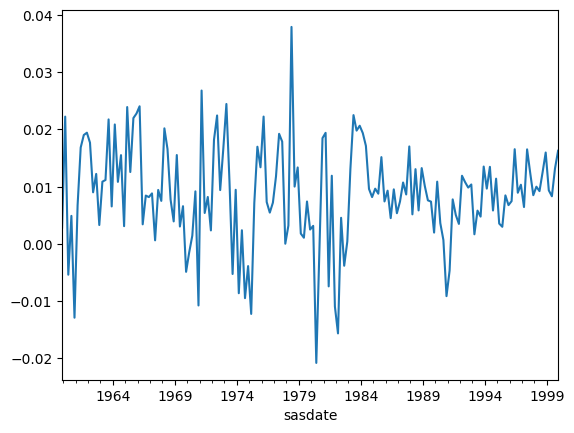

In [33]:
gdp_train.plot()

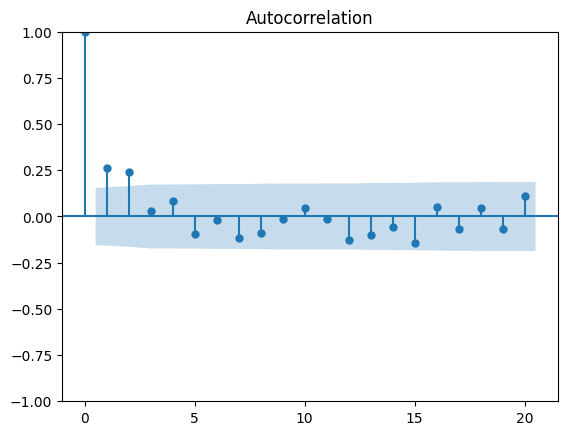

In [34]:
plot_acf(gdp_train, lags=20);

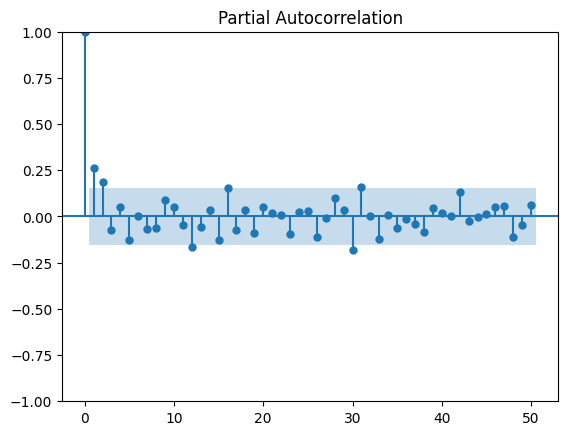

In [35]:
plot_pacf(gdp_train, lags=50);

The ACF and PACF plots both show peaks at lags 1 and 2. We thus choose to model with an ARMA(2, 2) process.

In [36]:
arma_model = ARIMA(gdp_train, order=(2,0,2))
arma_model_fit = arma_model.fit()
arma_model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  GDPC1   No. Observations:                  161
Model:                 ARIMA(2, 0, 2)   Log Likelihood                 543.257
Date:                Wed, 12 Feb 2025   AIC                          -1074.513
Time:                        21:44:43   BIC                          -1056.025
Sample:                    12-01-1959   HQIC                         -1067.006
                         - 12-01-1999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0087      0.001      7.288      0.000       0.006       0.011
ar.L1         -0.3748      0.199     -1.880      0.060      -0.766       0.016
ar.L2          0.5152      0.193      2.675      0.007       0.138       0.893
ma.L1          0.6173      0.237      2.603      0.009       0.153       1.082
ma.L2         -0.1957      0.228     -0.858      0.391      -0.643       0.252
sigma2      6.846e-05   5.85e-06     11.712      0.000     5.7e-05    7.99e-05
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                17.00
Prob(Q):                              0.96   Prob(JB):                         0.00
Heteroskedasticity (H):               0.30   Skew:                            -0.04
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.59
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [37]:
arma_model2 = ARIMA(gdp_train, order=(2,0,0))
arma_model2_fit = arma_model2.fit()
arma_model2_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  GDPC1   No. Observations:                  161
Model:                 ARIMA(2, 0, 0)   Log Likelihood                 541.653
Date:                Wed, 12 Feb 2025   AIC                          -1075.307
Time:                        21:44:43   BIC                          -1062.981
Sample:                    12-01-1959   HQIC                         -1070.302
                         - 12-01-1999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0087      0.001      7.539      0.000       0.006       0.011
ar.L1          0.2099      0.076      2.761      0.006       0.061       0.359
ar.L2          0.1895      0.068      2.792      0.005       0.056       0.322
sigma2      6.994e-05   6.01e-06     11.642      0.000    5.82e-05    8.17e-05
===================================================================================
Ljung-Box (L1) (Q):                   0.05   Jarque-Bera (JB):                13.69
Prob(Q):                              0.82   Prob(JB):                         0.00
Heteroskedasticity (H):               0.27   Skew:                            -0.02
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.43
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

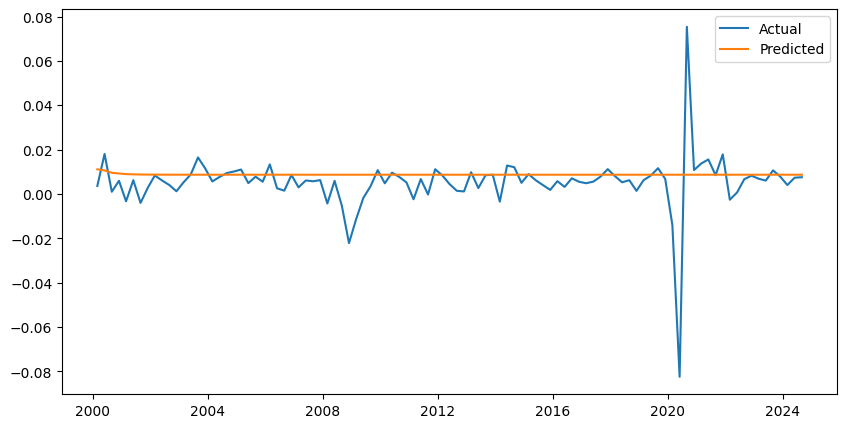

In [38]:
pred = arma_model2_fit.forecast(len(gdp_test))
plt.figure(figsize=(10,5))
plt.plot(gdp_test)
plt.plot(pred)
plt.legend(['Actual', 'Predicted'])
plt.show()

In [39]:
def evaluate(y_true, y_pred):
    print('Root Mean Squared Error:', root_mean_squared_error(y_true, y_pred))
    tp, fn, fp, tn = confusion_matrix(y_true < 0, y_pred < 0, labels=[True, False]).ravel()
    print(f"{tp = }, {fn = }, {fp = }, {tn = }")
    # Contraction prediction
    print(classification_report(y_true < 0,
                                y_pred < 0, labels=[True, False]))

In [40]:
evaluate(gdp_test, pred)

Root Mean Squared Error: 0.013217453975262056
tp = np.int64(0), fn = np.int64(13), fp = np.int64(0), tn = np.int64(86)
              precision    recall  f1-score   support

        True       0.00      0.00      0.00        13
       False       0.87      1.00      0.93        86

    accuracy                           0.87        99
   macro avg       0.43      0.50      0.46        99
weighted avg       0.75      0.87      0.81        99



/Users/wy/Documents/databusters-team-30/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/wy/Documents/databusters-team-30/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/wy/Documents/databusters-team-30/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

In [41]:
predictions_rolling = pd.Series()
gdp_train_rolling = gdp_train.copy()
for end_date in gdp_test.index:
  rolling_arma_model = ARIMA(gdp_train_rolling, order=(2,0,0))
  rolling_arma_model_fit = rolling_arma_model.fit()
  pred = rolling_arma_model_fit.predict(end_date)
  predictions_rolling.loc[end_date] = pred.loc[end_date]
  gdp_train_rolling.loc[end_date] = gdp_test.loc[end_date]

/Users/wy/Documents/databusters-team-30/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/wy/Documents/databusters-team-30/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/wy/Documents/databusters-team-30/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/wy/Documents/databusters-team-30/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likeliho

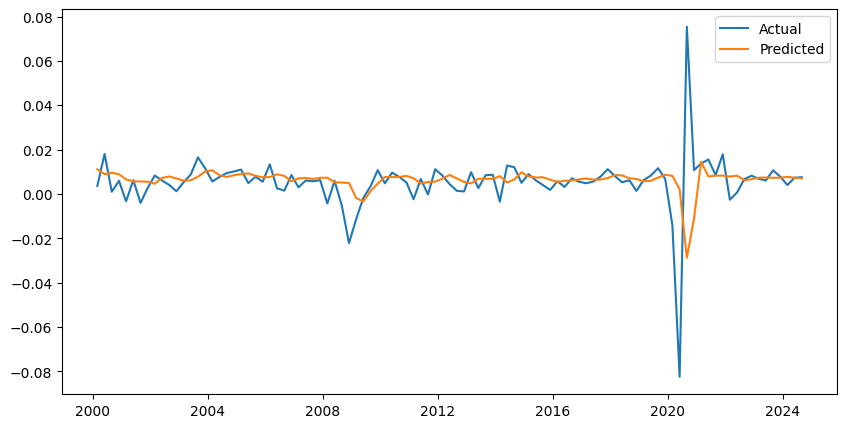

In [42]:
plt.figure(figsize=(10,5))
plt.plot(gdp_test)
plt.plot(predictions_rolling)
plt.legend(['Actual', 'Predicted'])
plt.show()

In [43]:
evaluate(gdp_test, predictions_rolling)

Root Mean Squared Error: 0.014866314286102819
tp = np.int64(2), fn = np.int64(11), fp = np.int64(2), tn = np.int64(84)
              precision    recall  f1-score   support

        True       0.50      0.15      0.24        13
       False       0.88      0.98      0.93        86

    accuracy                           0.87        99
   macro avg       0.69      0.57      0.58        99
weighted avg       0.83      0.87      0.84        99



## Forecasting

In [44]:
model = ARIMA(pd.concat([gdp_train, gdp_test]), order=(2,0,0))
model_fit = model.fit()
np.exp(model_fit.forecast(5))

/Users/wy/Documents/databusters-team-30/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


2024-12-01    1.007415
2025-03-01    1.007431
2025-06-01    1.007413
2025-09-01    1.007415
2025-12-01    1.007413
Freq: 3MS, Name: predicted_mean, dtype: float64

In [45]:
model_fit.aic, model_fit.bic

(np.float64(-1620.1899249112616), np.float64(-1605.9471983871995))

# VAR Model

In [46]:
train_unlagged = quarterly_merged[:cutoff].dropna()
test_unlagged = quarterly_merged[cutoff:]

In [47]:
scaler = StandardScaler()
scaler.set_output(transform='pandas')
train_unlagged_scaled = scaler.fit_transform(train_unlagged)

In [48]:
from statsmodels.tsa.api import VAR

var_model = VAR(train_unlagged_scaled)
var_model_fitted = var_model.fit(maxlags=1, ic='aic')
# var_results.summary()

In [49]:
forecast = var_model_fitted.forecast(var_model_fitted.endog, steps=len(test_unlagged))
forecast_df = pd.DataFrame(forecast, columns=train_unlagged_scaled.columns, index=test_unlagged.index)

forecast_df_unscaled = scaler.inverse_transform(forecast_df)
forecast_df_unscaled = pd.DataFrame(forecast_df_unscaled, columns = train_unlagged.columns, index = test_unlagged.index)

evaluate(test_unlagged['GDPC1'], forecast_df_unscaled['GDPC1'])

Root Mean Squared Error: 0.01362423972101768
tp = np.int64(0), fn = np.int64(13), fp = np.int64(0), tn = np.int64(86)
              precision    recall  f1-score   support

        True       0.00      0.00      0.00        13
       False       0.87      1.00      0.93        86

    accuracy                           0.87        99
   macro avg       0.43      0.50      0.46        99
weighted avg       0.75      0.87      0.81        99



/Users/wy/Documents/databusters-team-30/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/wy/Documents/databusters-team-30/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/wy/Documents/databusters-team-30/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

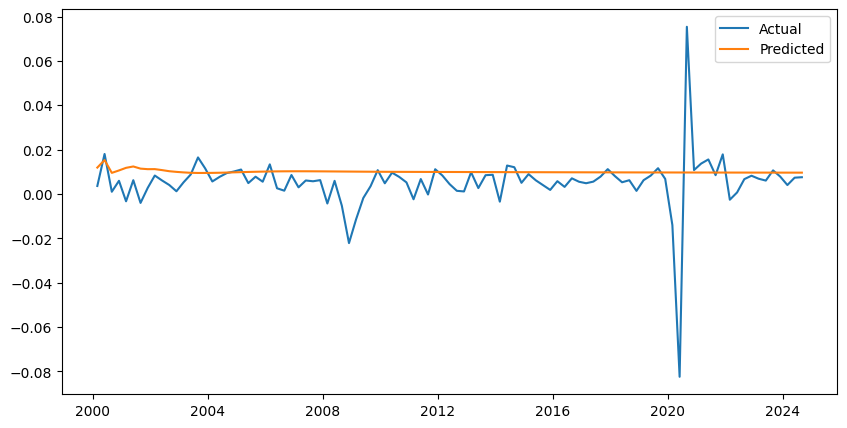

In [50]:
plt.figure(figsize=(10,5))
plt.plot(test_unlagged['GDPC1'])
plt.plot(forecast_df_unscaled['GDPC1'])
plt.legend(['Actual', 'Predicted'])
plt.show()

Root Mean Squared Error: 0.010207513595205973
tp = np.int64(5), fn = np.int64(8), fp = np.int64(4), tn = np.int64(82)
              precision    recall  f1-score   support

        True       0.56      0.38      0.45        13
       False       0.91      0.95      0.93        86

    accuracy                           0.88        99
   macro avg       0.73      0.67      0.69        99
weighted avg       0.86      0.88      0.87        99



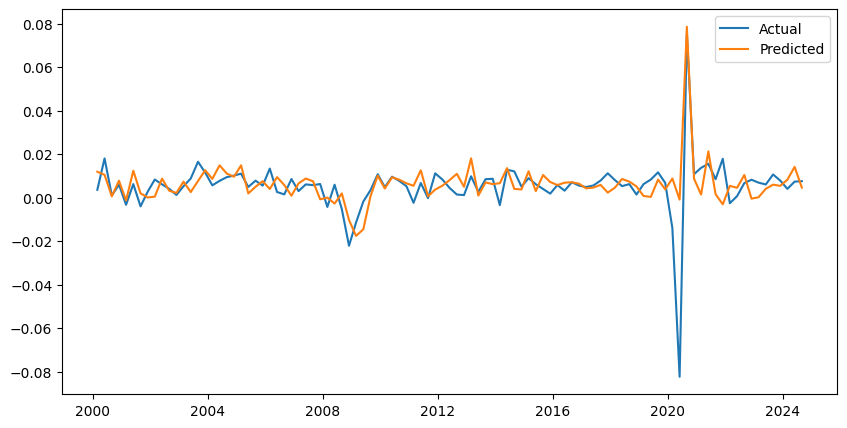

In [51]:
predictions_rolling_var = pd.DataFrame(index=test_unlagged.index, columns=test_unlagged.columns)
train_data_rolling_var = train_unlagged_scaled.copy()

for end_date in test_unlagged.index:
    var_model_rolling = VAR(train_data_rolling_var)
    var_model_rolling_fit = var_model_rolling.fit(maxlags=1, ic='aic')

    forecast = var_model_rolling_fit.forecast(var_model_rolling_fit.endog, steps=1)
    forecast_df = pd.DataFrame(forecast, columns=train_data_rolling_var.columns, index=[end_date])

    forecast_df_unscaled = scaler.inverse_transform(forecast_df)
    forecast_df_unscaled = pd.DataFrame(forecast_df_unscaled, columns = train_unlagged.columns, index = [end_date])

    predictions_rolling_var.loc[end_date] = forecast_df_unscaled.loc[end_date]

    new_data_point = test_unlagged.loc[end_date]
    new_data_point_scaled = scaler.transform(pd.DataFrame(new_data_point).T)
    train_data_rolling_var.loc[end_date, ] = new_data_point_scaled.loc[end_date]


evaluate(test_unlagged['GDPC1'], predictions_rolling_var['GDPC1'])

plt.figure(figsize=(10,5))
plt.plot(test_unlagged['GDPC1'])
plt.plot(predictions_rolling_var['GDPC1'])
plt.legend(['Actual', 'Predicted'])
plt.show()

## Forecasting

Here, we perform forecasting for Q1, Q2 and Q5 2025

In [61]:
var_model_rolling = VAR(train_data_rolling_var)
var_model_rolling_fit = var_model_rolling.fit(maxlags=1, ic='aic')

In [62]:
forecast = var_model_rolling_fit.forecast(var_model_rolling_fit.endog, steps=5)
forecast_df = pd.DataFrame(forecast, columns=train_data_rolling_var.columns)

In [63]:
forecast_df_unscaled = scaler.inverse_transform(forecast_df)
forecast_df_unscaled = pd.DataFrame(forecast_df_unscaled, columns = train_unlagged.columns, index=['2024-12-01', '2025-03-01', '2025-06-01', '2025-09-01', '2025-12-01'])

In [64]:
forecast_df_unscaled

,GDPC1,PCECC96,SLCEx,DPIC96,CUMFNS,MANEMP,DMANEMP,USCONS,USMINE,UNRATE,AWHMAN,HOUST,CMRMTSPLx,ANDENOx,DDURRG3Q086SBEA,OPHMFG,IPMANSICS,T5YFFM,S&P 500,bond_yield_spread,CMRMTSPLx_0,CMRMTSPLx_1,CMRMTSPLx_2,IPMANSICS_0,IPMANSICS_1,IPMANSICS_2,CUMFNS_0,CUMFNS_1,CUMFNS_2,UNRATE_0,UNRATE_1,UNRATE_2,USCONS_0,USCONS_1,USCONS_2,MANEMP_0,MANEMP_1,MANEMP_2,DMANEMP_0,DMANEMP_1,DMANEMP_2,AWHMAN_0,AWHMAN_1,AWHMAN_2,HOUST_0,HOUST_1,HOUST_2,ANDENOx_0,ANDENOx_1,ANDENOx_2,S&P 500_0,S&P 500_1,S&P 500_2,T5YFFM_0,T5YFFM_1,T5YFFM_2,BAAFFM_0,BAAFFM_1,BAAFFM_2,bond_yield_spread_0,bond_yield_spread_1,bond_yield_spread_2
2024-12-01,0.003139,0.001964,0.000790,0.001152,76.845250,-0.001937,-0.002746,0.004942,0.003032,-0.021930,40.665515,0.022700,0.040224,0.000007,0.000352,-0.007028,0.004079,-1.349216,0.002952,0.729360,-0.006784,0.003998,0.004643,-0.001993,0.010108,0.001808,-0.226682,0.746332,0.073206,0.096176,-0.094350,0.134281,-0.002034,0.004621,0.001936,-0.002757,0.002106,0.002084,-0.004001,0.002811,0.002791,40.584597,40.738915,40.673137,7.240176,7.216102,7.186204,0.092347,-0.019160,-0.018697,0.005102,-0.019792,-0.008928,-1.585915,-1.235733,-1.225778,0.120076,0.410846,0.458818,0.714949,0.721086,0.752037
2025-03-01,0.003358,0.000658,0.000436,0.010610,76.605667,-0.002942,-0.003413,0.003245,0.012715,0.370176,40.651415,-0.037476,0.015634,0.026678,-0.000053,0.009796,-0.001594,-1.132866,-0.003168,0.824008,-0.006672,0.001385,0.003985,-0.006541,-0.000678,0.002290,-0.499742,-0.114205,0.097635,0.397207,-0.081136,-0.092593,-0.004909,0.007009,0.001824,-0.005681,0.000134,0.001629,-0.006869,-0.000354,0.002633,40.675623,40.655147,40.623575,7.214143,7.156140,7.159341,0.058151,0.060530,-0.052532,0.010354,-0.000871,-0.001646,-1.265348,-1.047376,-1.085687,0.439038,0.772128,0.949157,0.771964,0.812644,0.887367
2025-06-01,0.002909,0.004285,0.002582,0.002979,76.153334,-0.004815,-0.005189,0.002958,0.011439,0.147991,40.551118,-0.014887,0.022956,-0.003899,0.001172,-0.003954,-0.004400,-0.762096,0.014623,1.023758,-0.003159,0.002336,-0.001024,-0.006117,0.001572,-0.001921,-0.467267,0.070707,-0.196449,0.319523,-0.100220,-0.047302,-0.003895,0.005152,-0.000447,-0.005658,-0.000707,0.000530,-0.006691,-0.001113,0.001804,40.521353,40.621981,40.510027,7.175434,7.149604,7.159304,0.043890,-0.002424,-0.002115,0.009068,0.010509,-0.001069,-1.014430,-0.690640,-0.581087,1.071653,1.495416,1.699857,0.967067,1.020349,1.083745
2025-09-01,0.002788,0.003834,0.001473,0.006585,75.550438,-0.005940,-0.006490,-0.000950,0.005231,0.143809,40.475261,-0.016368,0.009455,0.001288,-0.000430,0.002279,-0.007091,-0.372416,0.018019,1.146594,-0.002392,0.000707,-0.000278,-0.005844,-0.000201,-0.001096,-0.427339,-0.049331,-0.124993,0.272043,-0.073678,-0.041991,-0.004373,0.003231,-0.000492,-0.005249,-0.001285,0.000128,-0.006215,-0.002073,0.000812,40.427371,40.521351,40.476991,7.158702,7.132124,7.143570,0.017219,0.037653,-0.023010,0.008724,0.009351,-0.000187,-0.494261,-0.307846,-0.315039,1.779352,2.049298,2.142661,1.117724,1.137527,1.184423
2025-12-01,0.003774,0.005570,0.001400,0.006925,75.142302,-0.005584,-0.006547,0.000037,0.004435,0.121234,40.467200,-0.002733,0.008444,0.010585,-0.000030,0.001816,-0.004695,-0.143000,0.020567,1.201975,0.000072,0.000282,0.000829,-0.004423,0.000289,0.000945,-0.324860,-0.007064,0.043085,0.239786,-0.066900,-0.063625,-0.002822,0.002934,0.000461,-0.004771,-0.000757,0.000092,-0.005803,-0.001180,0.000565,40.429454,40.496607,40.475466,7.148377,7.136380,7.141485,0.028793,0.044073,-0.018095,0.011939,0.009504,-0.003239,-0.251646,-0.083949,-0.093329,2.184627,2.376176,2.440076,1.193301,1.186168,1.226365


In [65]:
forecast_df_unscaled['GDPC1']

2024-12-01    0.003139
2025-03-01    0.003358
2025-06-01    0.002909
2025-09-01    0.002788
2025-12-01    0.003774
Name: GDPC1, dtype: float64

In [66]:
np.exp(forecast_df_unscaled['GDPC1'])

2024-12-01    1.003144
2025-03-01    1.003363
2025-06-01    1.002913
2025-09-01    1.002792
2025-12-01    1.003781
Name: GDPC1, dtype: float64

# Unused Models

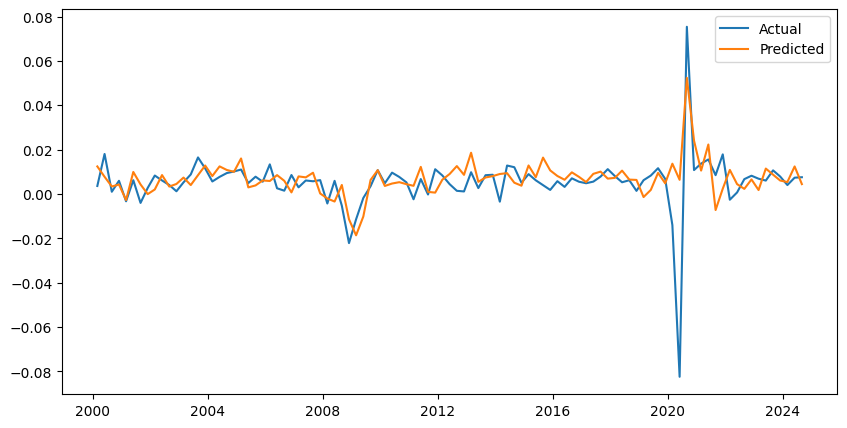

Root Mean Squared Error: 0.011276541972503263
tp = np.int64(5), fn = np.int64(8), fp = np.int64(4), tn = np.int64(82)
              precision    recall  f1-score   support

        True       0.56      0.38      0.45        13
       False       0.91      0.95      0.93        86

    accuracy                           0.88        99
   macro avg       0.73      0.67      0.69        99
weighted avg       0.86      0.88      0.87        99



In [67]:
# Treating as Exogenous variables

scaler = StandardScaler()
scaler.set_output(transform='pandas')
train_data_scaled = scaler.fit_transform(train_data)

significant_exog_features = set(train_data_scaled.columns) - {'GDPC1'}

arimax_model_fitted = None

arimax_model = SARIMAX(train_data_scaled['GDPC1'],
                order=(0, 0, 0),
                seasonal_order=(0, 0, 0, 0),
                exog=train_data_scaled.loc[:, list(significant_exog_features)],
                time_varying_regression=False,
                mle_regression=True)
arimax_model_fitted = arimax_model.fit()

test_data_scaled = scaler.transform(test_data)
pred = arimax_model_fitted.forecast(len(gdp_test), exog=test_data_scaled.loc[:, list(significant_exog_features)])
test_data_scaled_pred = test_data_scaled.copy()
test_data_scaled_pred['GDPC1'] = pred
test_data_scaled_pred['GDPC1'] = scaler.inverse_transform(test_data_scaled_pred)[:,0]

plt.figure(figsize=(10,5))
plt.plot(gdp_test)
plt.plot(test_data_scaled_pred['GDPC1'])
plt.legend(['Actual', 'Predicted'])
plt.show()

evaluate(gdp_test, test_data_scaled_pred['GDPC1'])

In [60]:
# LSTM

# quarterly_merged_stationary = quarterly_merged.dropna()

# quarterly_x = quarterly_merged_stationary.drop(columns = ['GDPC1'])
# quarterly_y = quarterly_merged_stationary['GDPC1']

# test_size = int(quarterly_merged_stationary.shape[0]*0.15)
# quarterly_x_train_valid = quarterly_x.iloc[:test_size]
# quarterly_x_test = quarterly_x.iloc[test_size:]
# quarterly_y_train_valid = quarterly_y.iloc[:test_size]
# quarterly_y_test = quarterly_y.iloc[test_size:]

# tscv = TimeSeriesSplit(n_splits=5)

# def create_sequences(X, y, look_back):
#   Xs, ys = [], []
#   for i in range(len(X) - look_back):
#     Xs.append(X.iloc[i:(i + look_back)].values)
#     ys.append(y.iloc[i + look_back])
#   return np.array(Xs), np.array(ys)

# def create_lstm_model(input_shape):
#   model = Sequential([
#     LSTM(50, activation='tanh', input_shape=input_shape),
#     Dropout(0.2),
#     Dense(1, activation='linear')
# ])

# look_back = 4
# X_seq, y_seq = create_sequences(quarterly_x_train_valid, quarterly_y_train_valid, look_back)

# n_splits = 5
# tscv = TimeSeriesSplit(n_splits=n_splits)

# mse_scores = []

# for train_idx, test_idx in tscv.split(X_seq):
#   X_train, y_train = X_seq[train_idx], y_seq[train_idx]
#   X_valid, y_valid = X_seq[test_idx], y_seq[test_idx]

#   num_train_samples, timesteps, num_features = X_train.shape

#   model = Sequential()
#   model.add(LSTM(units=50, activation='tanh', input_shape=(timesteps, num_features)))
#   model.add(Dense(units=1, activation='linear'))
#   model.compile(optimizer='adam', loss='mse', metrics=['mse'])

#   model.fit(X_train, y_train, epochs=100, batch_size=8)

#   predictions = model.predict(X_valid)
#   mse = np.mean((predictions - y_valid) ** 2)
#   print("Mean Squared Error:", mse)
#   mse_scores.append(mse)

# print(f"\nAverage MSE over {n_splits} folds: {np.mean(mse_scores):.4f}")